In [2]:
try:
  import gensim.downloader as api
  import gensim
except:
  !pip install gensim
  import gensim.downloader as api
  import gensim

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

In [3]:
# import word2vex
w2v = api.load('word2vec-google-news-300')

In [4]:
word2start = "king"
word2subtract = "man"
word2add = "queen"

allwords = list(w2v.key_to_index.keys())

for word in [word2start, word2subtract, word2add]:
  if word not in allwords:
    print(f"{word} not in vocabulary")

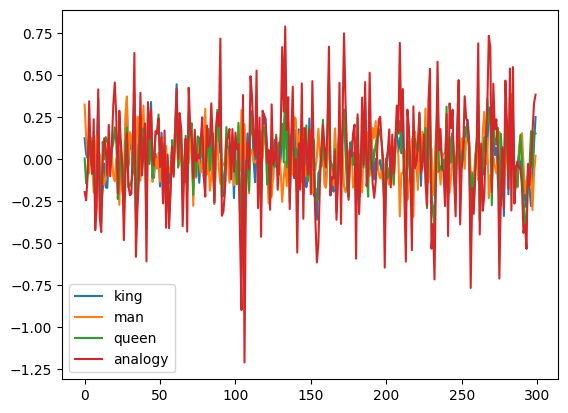

In [42]:
# Get the embedding vectors for the words
v1 = w2v[word2start]
v2 = w2v[word2subtract]
v3 = w2v[word2add]

# Calculate the analogy vector
analogy_vector = v1 - v2 + v3

# Plot the vectors
plt.plot(v1, label=word2start)
plt.plot(v2, label=word2subtract)
plt.plot(v3, label=word2add)
plt.plot(analogy_vector, label="analogy")

plt.legend()
plt.show()

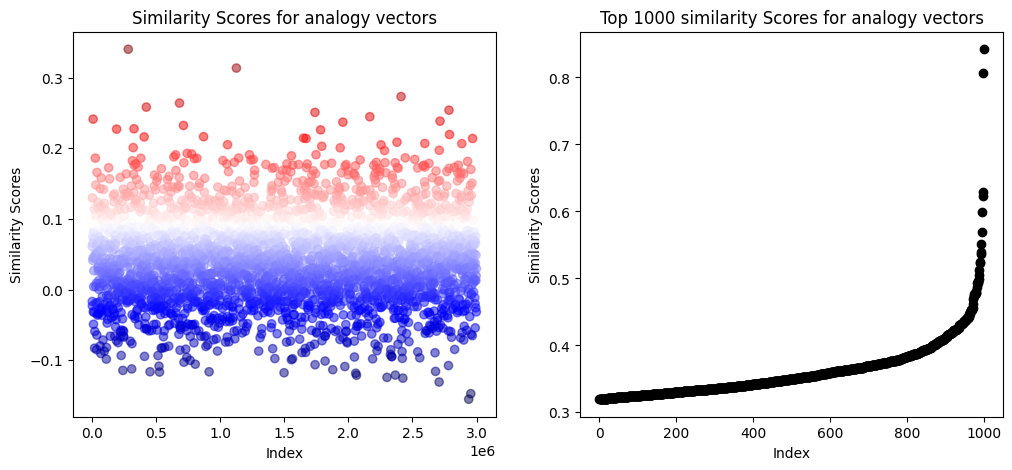

In [43]:
# calculate cosine similarities of the analogy vector with all the embedding vectors
similarities = w2v.cosine_similarities(analogy_vector, w2v.vectors)

# find the top 100 similarities
n = 1000
top_similarities = w2v.most_similar(analogy_vector, topn=n)

top_sc = sorted([x[1] for x in top_similarities])

# Plot the results
_, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot every k records
k = 1000
axs[0].scatter(np.arange(0,len(similarities),k),similarities[::k], marker='o',c=similarities[::k],cmap='seismic', alpha=.5)
axs[0].set_xlabel('Index')
axs[0].set_ylabel('Similarity Scores')
axs[0].set_title('Similarity Scores for analogy vectors')

axs[1].plot(top_sc, 'ko')
axs[1].set_xlabel('Index')
axs[1].set_ylabel('Similarity Scores')
axs[1].set_title(f'Top {n} similarity Scores for analogy vectors')

plt.show()

In [44]:
# Print the top 10 similarities and their similarity scores
print("Top 10 similar words:")
print('\n'.join([f'Word "{word:30}" with similarity score {sc:>5.2f}' for word, sc in top_similarities[:10]]))

Top 10 similar words:
Word "queen                         " with similarity score  0.84
Word "king                          " with similarity score  0.81
Word "queens                        " with similarity score  0.63
Word "monarch                       " with similarity score  0.62
Word "kings                         " with similarity score  0.60
Word "princess                      " with similarity score  0.57
Word "royal                         " with similarity score  0.55
Word "princes                       " with similarity score  0.54
Word "NYC_anglophiles_aflutter      " with similarity score  0.54
Word "Queen_Consort                 " with similarity score  0.52


In [56]:
# Create a function to test the top analogies
def get_analogy(start, subtract, add, k):

  # Return an error if any of the words is not in the vocab
  for word in [start, subtract, add]:
    if word not in allwords:
      print(f'The word {word} does not exist in vocabulary')
      return

  # Print the analogy
  print(f'{start} is to {subtract} as "____" is to {add}')

  # Create the vectors
  v1 = w2v[start]
  v2 = w2v[subtract]
  v3 = w2v[add]

  # Create the analogy vector
  analogy_vector = v1 - v2 + v3

  # Calculate the cosine similarities of the analogy
  similarities = w2v.cosine_similarities(analogy_vector, w2v.vectors)

  # Get the top k highest scores
  top_similarities = w2v.most_similar(analogy_vector, topn=k)

  print(f"Top {k} similar words:")
  print('\n'.join([f'Word "{word:30}" with similarity score {sc:>5.2f}' for word, sc in top_similarities]))

  return

In [58]:
get_analogy("tree", "leaf", "petal", 10)
#

tree is to leaf as "____" is to petal
Top 10 similar words:
Word "petal                         " with similarity score  0.73
Word "tree                          " with similarity score  0.67
Word "pine_tree                     " with similarity score  0.53
Word "oak_tree                      " with similarity score  0.52
Word "trees                         " with similarity score  0.51
Word "tree_trunk                    " with similarity score  0.51
Word "redwood_tree                  " with similarity score  0.50
Word "willow_tree                   " with similarity score  0.50
Word "petals                        " with similarity score  0.49
Word "tree_limb                     " with similarity score  0.48
